In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = "/home/yihelu/habitat-insect/examples/dataset-val/mbcx"
# data_dir = "/home/yihelu/habitat-insect/examples/tutorials"

json_list = []
for file in os.listdir(data_dir):
    if file.endswith('.json'): json_list.append(file)
json_list = np.sort(json_list)

In [3]:
spl = {}

for data_file in json_list[:]:
    # Open the JSON file
    with open(os.path.join(data_dir, data_file), 'r') as file:
        # Load the contents of the file into a dictionary
        data = json.load(file)

        trial_name = data['trial_name'].split('_')
        
        episode_id = '{}_{}'.format(trial_name[0].split('.')[0], trial_name[1])
        trial_id = trial_name[3]

        if episode_id not in spl:
            spl[episode_id] = {}
        spl[episode_id][trial_id] = data['spl']

In [4]:
data.keys()

dict_keys(['trial_name', 'scene_id', 'episode_id', 'start_position', 'goal_position', 'final_distance_to_goal', 'success', 'spl', 'collision_count', 'position', 'rotation', 'pointgoal_with_gps_compass', 'is_collision', 'angle_to_escape', 'collision_direction'])

In [5]:
def spl_histogram(ax, spl, success):
    counts, bins = np.histogram(1 - np.array(spl), bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1])
    ax.bar(bins[:-1] - 0.1, np.flip(counts), width=0.1, align='edge')
    ax.axvline(np.mean(spl), color='k')
    print(np.mean(success), np.mean(spl))

In [6]:
spl_summary = {'first': [], 'last': [], 'mean': [], 'best': [], 'sorted': [], 'time2best': []}
success_summary = {'first': [], 'last': [], 'mean': [], 'best': [], 'sorted': []}

for spl_all in spl.values():
    spl_trial = []
    for trial_id in range(20):
        if str(trial_id) in spl_all:
            spl_val = spl_all[str(trial_id)]
            spl_trial.append(spl_val)
        else:
            # break
            spl_trial.append(spl_val)
            
    spl_summary['first'].append(spl_trial[0])
    spl_summary['last'].append(spl_trial[-1])
    spl_summary['mean'].append(np.mean(spl_trial))
    spl_summary['best'].append(np.max(spl_trial))
    spl_summary['time2best'].append(np.argmax(spl_trial))
    spl_summary['sorted'].append(np.sort(spl_trial))
    
    success_summary['first'].append(np.count_nonzero(spl_trial[0]))
    success_summary['last'].append(np.count_nonzero(spl_trial[-1]))
    success_summary['mean'].append(np.count_nonzero(spl_trial) / len(spl_trial))
    success_summary['best'].append(int(np.any(spl_trial)))
    success_summary['sorted'].append(np.sign(np.sort(spl_trial)))

    

0.85 0.45729438227169183
0.73 0.4905714506906407
0.76 0.48657830094871896
0.93 0.6554024112146376


Text(0, 0.5, 'spl')

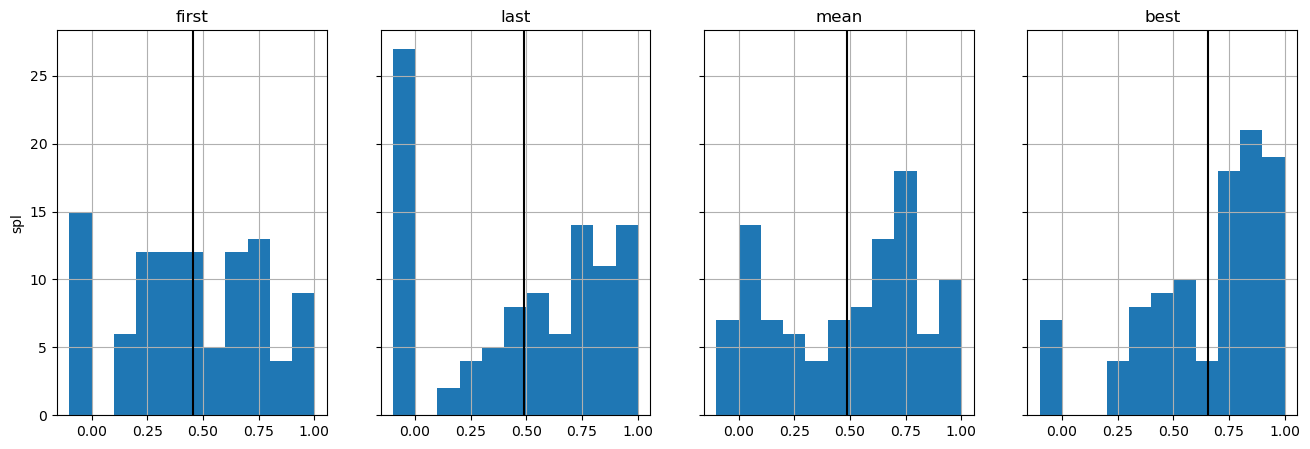

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, key in zip(axes, ('first', 'last', 'mean', 'best')):
    spl_histogram(ax, spl_summary[key], success_summary[key])
    ax.set_title(key)
    ax.grid()

axes[0].set_ylabel('spl')

In [8]:
spl_summary['sorted'] = np.array(spl_summary['sorted'])
success_summary['sorted'] = np.array(success_summary['sorted'])

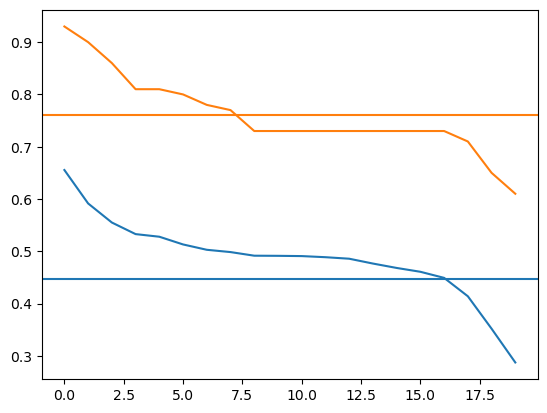

In [9]:
plt.plot(np.flip(np.mean(spl_summary['sorted'], axis=0)))
plt.plot(np.flip(np.mean(success_summary['sorted'], axis=0)))
plt.axhline(0.446)
plt.axhline(0.76, color='tab:orange')

23


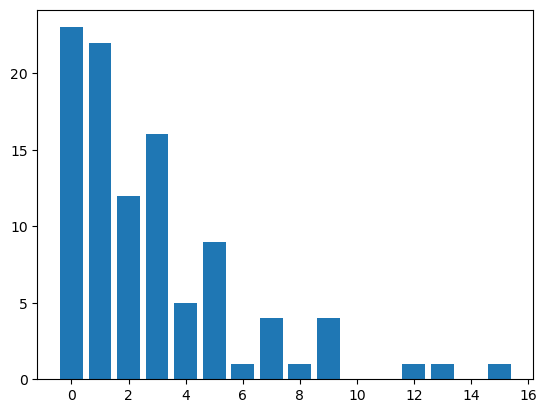

In [10]:
success_idx = spl_summary['best'] != 0
values, counts = np.unique(np.array(spl_summary['time2best'])[success_idx], return_counts=True)
plt.bar(values, counts)
print(counts[0])